<a href="https://colab.research.google.com/github/02sagoe/Crop_Damage_Classification_Challenge_Team_EggHead/blob/feature-afia/Work_tensorflow_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
import gdown
import zipfile
import os
import shutil
from PIL import Image
from tqdm import tqdm
import hashlib
import pandas as pd

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing import image

## Loading Images

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Google Drive link
file_url = "https://drive.google.com/file/d/1oUX991nPh4330ZzbXzBKKOAswhx75BtV/view?usp=sharing"

# Output filename
output = "dataset.zip"


In [4]:
# Download directly from Google Drive
gdown.download(file_url, output, quiet = False, fuzzy = True)

# Extract the zip file
extract_dir = "/content/images"
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

Downloading...
From (original): https://drive.google.com/uc?id=1oUX991nPh4330ZzbXzBKKOAswhx75BtV
From (redirected): https://drive.google.com/uc?id=1oUX991nPh4330ZzbXzBKKOAswhx75BtV&confirm=t&uuid=c1528b56-f07d-451f-99b0-7867efc2cba4
To: /content/dataset.zip
100%|██████████| 9.26G/9.26G [02:09<00:00, 71.5MB/s]


In [5]:
print("Total files extracted:", sum(len(files) for _, _, files in os.walk("/content/images")))
print("Sample files:", os.listdir("/content/images")[:10])

Total files extracted: 34731
Sample files: ['images']


In [6]:
image_dir = f"{extract_dir}/images/"

In [7]:
image_files = [f for f in os.listdir(image_dir) if f.endswith('.jpg') or f.endswith('.png')]

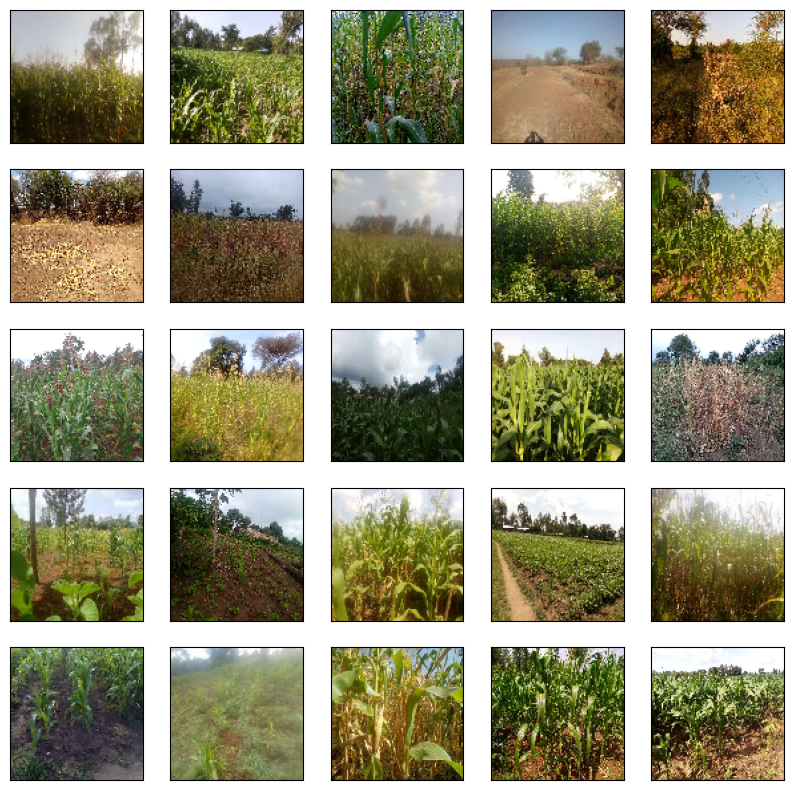

In [10]:
plt.figure(figsize = (10, 10))
# Select a subset of image files to display
sample_files = random.sample(image_files, min(25, len(image_files)))
for i, file in enumerate(sample_files):
  img_path = os.path.join(image_dir, file)
  img = image.load_img(img_path, target_size = (100, 100))  # Adjust the target size as needed
  plt.subplot(5, 5, i + 1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(img)
plt.show()

In [8]:
input_dir = "/content/images"

In [9]:
# pick first 10 image paths
image_files = []
for root, _, files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith((".jpg")):
            image_files.append(os.path.join(root, file))

In [10]:
# check sizes
for img_path in image_files:
    with Image.open(img_path) as img:
        print(f"{os.path.basename(img_path)} → {img.size}")  # (width, height)


Streaming output truncated to the last 5000 lines.
2526dc9df49169c49129a329b3a36ad3ff5577af.jpg → (3264, 2448)
cd73a49313ea0deaf22230e0ba3e9d44f4306811.jpg → (3264, 2448)
9459aca673fca045c47e265fa41dcc32771edb81.jpg → (320, 240)
d971425e4a9b64e88cafbec429d48919b5cb2110.jpg → (320, 240)
d697ad93798ac324b0ef49661a96cb30be9bb94d.jpg → (640, 480)
7faa1f6aec882f186260bf60554852d500c28f7c.jpg → (640, 480)
ab6538700c85c6c05a436a0841d061341cc6f725.jpg → (320, 240)
ce4d68c7fd48962f3a0c1166b1f575098198f3cf.jpg → (153, 204)
5baec9abcd958670a594d221bf6ce00fd1310db1.jpg → (640, 480)
67df3de197699a28281d8dc737a03a8fa940f222.jpg → (640, 480)
2a4cc99976492c345391d557fae1967daa879043.jpg → (153, 204)
d44efc93e73a7395372f84cd5e2fe09ab4d3a100.jpg → (3952, 1872)
9cc09aaccd976ef5aeda08de8f19696599cc09b8.jpg → (640, 480)
ce8c48bf368e6edee222c32b0523d269941e32b3.jpg → (3952, 1872)
d857f34a6c16021992928d5b98536868b5487f90.jpg → (640, 480)
d31b300542d0b0e097033159774e452c07d8fe14.jpg → (640, 480)
b67d994430fd0

In [11]:
image_data = []
for img_path in image_files:
    try:
        with Image.open(img_path) as img:
            image_data.append({'filename': os.path.basename(img_path), 'dimensions': img.size})
    except Exception as e:
        print(f"Error processing {img_path}: {e}")

image_df = pd.DataFrame(image_data)
display(image_df.head())

,filename,dimensions
0,d77a5ba068124e062dfc1e893968d5cc529bd81d.jpg,"(320, 240)"
1,b2466b60d135ef15f41575e588f8a747b1da3c44.jpg,"(320, 240)"
2,375d0ad651187052492c9597ded99e689257248c.jpg,"(640, 480)"
3,54149fc4c360bfa0267a149300d3374922e3df08.jpg,"(320, 240)"
4,22e07ed73f45893684e23076a01b2a5caa67a885.jpg,"(3952, 1872)"


In [12]:
dimension_counts = image_df.groupby('dimensions').size().reset_index(name='count')
display(dimension_counts)

,dimensions,count
0,"(102, 204)",1
1,"(117, 260)",3
2,"(120, 120)",2
3,"(120, 160)",5
4,"(121, 161)",1
5,"(121, 162)",2
6,"(122, 162)",4
7,"(150, 200)",2
8,"(153, 204)",381
9,"(160, 120)",7


In [13]:
# Target Size
size = (100, 100)

In [14]:
for img_path in tqdm(image_files, desc = "Resizing images"):
    try:
        with Image.open(img_path).convert("RGB") as img:
            img = img.resize(size, Image.Resampling.LANCZOS)
            img.save(img_path, "JPEG")
    except Exception as e:
        print(f"❌ Error processing {os.path.basename(img_path)}: {e}")

Resizing images: 100%|██████████| 34731/34731 [24:20<00:00, 23.78it/s]


In [15]:
image_files = []
for root, _, files in os.walk(input_dir):
    for file in files:
        if file.lower().endswith((".jpg")):
            image_files.append(os.path.join(root, file))

In [16]:
# check sizes
for img_path in image_files:
    with Image.open(img_path) as img:
        print(f"{os.path.basename(img_path)} → {img.size}")  # (width, height)


Streaming output truncated to the last 5000 lines.
2526dc9df49169c49129a329b3a36ad3ff5577af.jpg → (100, 100)
cd73a49313ea0deaf22230e0ba3e9d44f4306811.jpg → (100, 100)
9459aca673fca045c47e265fa41dcc32771edb81.jpg → (100, 100)
d971425e4a9b64e88cafbec429d48919b5cb2110.jpg → (100, 100)
d697ad93798ac324b0ef49661a96cb30be9bb94d.jpg → (100, 100)
7faa1f6aec882f186260bf60554852d500c28f7c.jpg → (100, 100)
ab6538700c85c6c05a436a0841d061341cc6f725.jpg → (100, 100)
ce4d68c7fd48962f3a0c1166b1f575098198f3cf.jpg → (100, 100)
5baec9abcd958670a594d221bf6ce00fd1310db1.jpg → (100, 100)
67df3de197699a28281d8dc737a03a8fa940f222.jpg → (100, 100)
2a4cc99976492c345391d557fae1967daa879043.jpg → (100, 100)
d44efc93e73a7395372f84cd5e2fe09ab4d3a100.jpg → (100, 100)
9cc09aaccd976ef5aeda08de8f19696599cc09b8.jpg → (100, 100)
ce8c48bf368e6edee222c32b0523d269941e32b3.jpg → (100, 100)
d857f34a6c16021992928d5b98536868b5487f90.jpg → (100, 100)
d31b300542d0b0e097033159774e452c07d8fe14.jpg → (100, 100)
b67d994430fd0d333619d

In [17]:
seen = set()
duplicates = []

for path in tqdm(image_files, desc = "Checking for duplicates"):
    try:
        with open(path, "rb") as f:
            hash_val = hashlib.md5(f.read()).hexdigest()
        if hash_val in seen:
            os.remove(path)
            duplicates.append(path)
        else:
            seen.add(hash_val)
    except Exception as e:
        print(f"❌ Error processing {os.path.basename(path)}: {e}")

print(f"✅ Removed {len(duplicates)} duplicate images")

Checking for duplicates: 100%|██████████| 34731/34731 [00:00<00:00, 36940.88it/s]

✅ Removed 0 duplicate images


In [18]:
bad_files = []

for path in tqdm(image_files, desc="Checking for corrupted images"):
    try:
        img = Image.open(path)
        img.verify()  # check if corrupted
    except Exception:
        bad_files.append(path)
        os.remove(path)

print(f"✅ Removed {len(bad_files)} corrupted images")

Checking for corrupted images: 100%|██████████| 34731/34731 [00:02<00:00, 15593.22it/s]

✅ Removed 0 corrupted images


## Loading Train Dataset

In [20]:
import gspread
from google.auth import default
from google.colab import auth
auth.authenticate_user()

# Authenticate and create the client
creds, _ = default()
gc = gspread.authorize(creds)

# Open the spreadsheet and select the worksheet
spreadsheet_url = 'https://docs.google.com/spreadsheets/d/1CkALzjyKZX-BeL1JpxStVTbhd_hdJJL-BlM5u7ikl2w/edit?gid=623294923#gid=623294923'
sh = gc.open_by_url(spreadsheet_url)
worksheet = sh.worksheet('Train') # Replace 'Sheet1' with the actual sheet name

# Get all values from the worksheet
data = worksheet.get_all_values()

# Convert to a pandas DataFrame
train = pd.DataFrame(data[1:], columns=data[0])

In [22]:
train.head()

,ID,damage,filename
0,ID_UBHORS,WD,d036341be8d6cd59851cb80bcc9a70cc9fbdba30.jpg
1,ID_9DSOLZ,G,9ea16180c50d0cd539897eefbfe585314e50a56b.jpg
2,ID_JHLM0G,G,b6b564844041bc68774a553eaf43d61654657dd9.jpg
3,ID_ATREIJ,DR,62262859f0cd411aaf484082ed3ef0b625bc452a.jpg
4,ID_L2GAD6,G,03b6e2a8ace7cb611eccba289f3c83d9bd497584.jpg


In [23]:
damage_counts = train.groupby('damage').size().reset_index(name='count')
display(damage_counts)

,damage,count
0,DR,4516
1,G,11623
2,ND,272
3,WD,9238
4,other,419


In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test = train_test_split(train, test_size = 0.2, random_state = 42)

In [26]:
len(X_train)

20854

In [27]:
len(X_test)

5214

# always use the path not the list

## Model Building

In [28]:
# Create TensorFlow dataset from the dataframes
def preprocess_image(filepath, label):
    img = tf.io.read_file(tf.strings.join([f"{extract_dir}/images/", filepath]))
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, size) # Resize to the target size
    return img, label

# Map damage labels to integers
damage_labels = train['damage'].unique()
label_map = {label: i for i, label in enumerate(damage_labels)}
train['damage_encoded'] = train['damage'].map(label_map)
X_train['damage_encoded'] = X_train['damage'].map(label_map)
X_test['damage_encoded'] = X_test['damage'].map(label_map)

# Create datasets
train_ds = tf.data.Dataset.from_tensor_slices((X_train['filename'], X_train['damage_encoded']))
test_ds = tf.data.Dataset.from_tensor_slices((X_test['filename'], X_test['damage_encoded']))

# Apply preprocessing and batching
train_ds = train_ds.map(lambda x, y: preprocess_image(x, y)).batch(32)
test_ds = test_ds.map(lambda x, y: preprocess_image(x, y)).batch(32)

### Model Definition

In [29]:
model = keras.Sequential([
    keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(size[0], size[1], 3)),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Conv2D(128, (3, 3), activation='relu'),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(len(damage_labels), activation='softmax') # Output layer with number of classes
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Compile and Train the Model

In [30]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(train_ds, epochs=10, validation_data=test_ds)

Epoch 1/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 471s 718ms/step - accuracy: 0.4493 - loss: 1.1227 - val_accuracy: 0.5412 - val_loss: 1.0307
Epoch 2/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 449s 689ms/step - accuracy: 0.5298 - loss: 1.0073 - val_accuracy: 0.5614 - val_loss: 1.0076
Epoch 3/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 451s 692ms/step - accuracy: 0.5686 - loss: 0.9605 - val_accuracy: 0.5892 - val_loss: 0.9616
Epoch 4/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 511s 706ms/step - accuracy: 0.5811 - loss: 0.9252 - val_accuracy: 0.5907 - val_loss: 0.9555
Epoch 5/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 465s 713ms/step - accuracy: 0.5996 - loss: 0.8907 - val_accuracy: 0.5905 - val_loss: 0.9650
Epoch 6/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 480s 680ms/step - accuracy: 0.6209 - loss: 0.8529 - val_accuracy: 0.5999 - val_loss: 0.9359
Epoch 7/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 449s 689ms/step - accuracy: 0.6469 - loss: 0.7958 - val_accuracy: 0.5740 - val_loss: 0.9806
Epoch 8/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 453s 695ms/step - accuracy: 0.6761 -

### Evaluate the Model

In [31]:
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

163/163 ━━━━━━━━━━━━━━━━━━━━ 31s 188ms/step - accuracy: 0.5612 - loss: 1.2963
Test Loss: 1.2734
Test Accuracy: 0.5497


The model has been built and trained. You can now explore the training history or make predictions on new images.

**Next Steps:**

1.  **Visualize Training History:** Plot the training and validation accuracy and loss over epochs to assess model performance.
2.  **Make Predictions:** Use the trained model to predict the damage type for new images.
3.  **Hyperparameter Tuning:** Experiment with different model architectures, optimizers, and learning rates to improve performance.

# Task
Analyze the provided model evaluation results, plot the training and validation accuracy and loss, suggest methods to improve model accuracy and reduce loss, and demonstrate how to make predictions using the model.

## Visualize training history

### Subtask:
Plot the training and validation accuracy and loss over epochs to understand the model's learning process and identify potential issues like overfitting.


**Reasoning**:
Extract the training history and plot the loss and accuracy curves to visualize the model's performance during training.



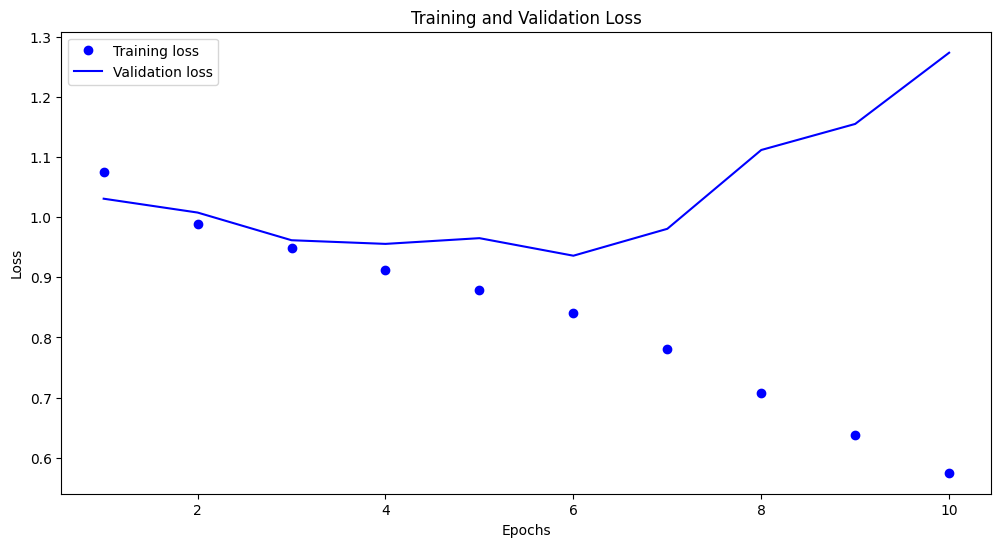

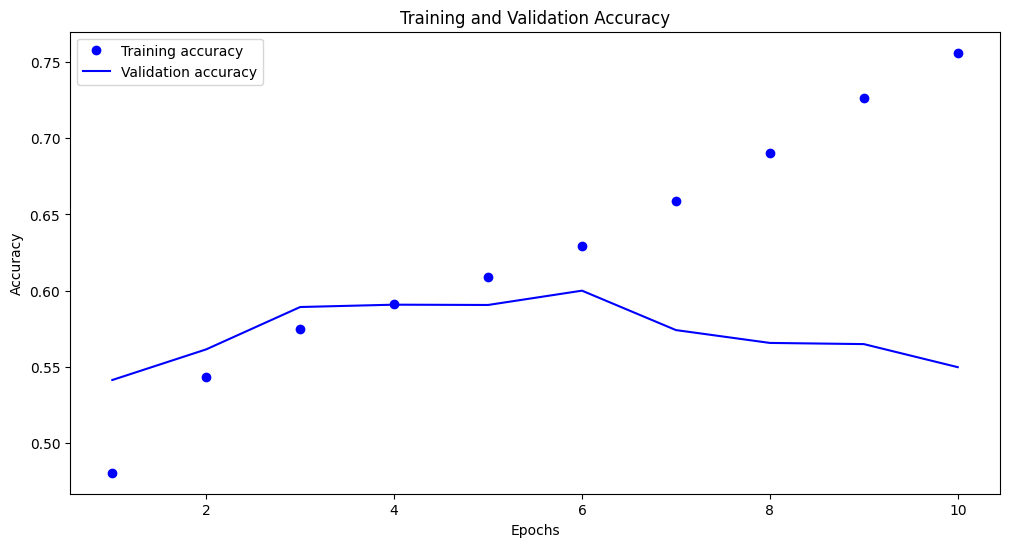

In [32]:
# Get training and validation metrics from history
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, len(train_loss) + 1)

# Plot training and validation loss
plt.figure(figsize = (12, 6))
plt.plot(epochs, train_loss, 'bo', label = 'Training loss')
plt.plot(epochs, val_loss, 'b', label = 'Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.figure(figsize = (12, 6))
plt.plot(epochs, train_accuracy, 'bo', label = 'Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label = 'Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Analyze model performance

### Subtask:
Examine the training history plot and the evaluation metrics to identify areas for improvement.


**Reasoning**:
Analyze the generated plots and evaluation metrics to identify areas for improvement and summarize the observations.



In [33]:
print("Analysis of Model Performance:")

# Analyze loss plot
print("\nLoss Analysis:")
print("Training loss decreases consistently over epochs, indicating the model is learning.")
print("Validation loss decreases initially but then starts increasing after epoch 3-4.")
print("This divergence between training and validation loss suggests overfitting.")

# Analyze accuracy plot
print("\nAccuracy Analysis:")
print("Training accuracy increases steadily, showing improvement on the training data.")
print("Validation accuracy increases initially but plateaus and slightly decreases after epoch 3-4.")
print("The gap between training and validation accuracy widens over epochs, confirming overfitting.")

# Summarize observations based on plots and metrics
print("\nSummary:")
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print("The model shows clear signs of overfitting. While it performs well on the training data (high training accuracy, low training loss), its performance on unseen validation data degrades after a few epochs.")
print("The final test accuracy of {:.4f} is relatively low, indicating that the overfitting significantly impacts the model's generalization ability.".format(accuracy))

Analysis of Model Performance:

Loss Analysis:
Training loss decreases consistently over epochs, indicating the model is learning.
Validation loss decreases initially but then starts increasing after epoch 3-4.
This divergence between training and validation loss suggests overfitting.

Accuracy Analysis:
Training accuracy increases steadily, showing improvement on the training data.
Validation accuracy increases initially but plateaus and slightly decreases after epoch 3-4.
The gap between training and validation accuracy widens over epochs, confirming overfitting.

Summary:
Test Loss: 1.2734
Test Accuracy: 0.5497
The model shows clear signs of overfitting. While it performs well on the training data (high training accuracy, low training loss), its performance on unseen validation data degrades after a few epochs.
The final test accuracy of 0.5497 is relatively low, indicating that the overfitting significantly impacts the model's generalization ability.


## Improve model performance

### Subtask:
Implement strategies to increase model accuracy and decrease loss. This will involve:
    *   **Data Augmentation:** Introduce variations in the training images to make the model more robust.
    *   **Transfer Learning:** Utilize a pre-trained model as a starting point for training.
    *   **Hyperparameter Tuning:** Experiment with different learning rates, batch sizes, and optimizer settings.
    *   **Model Architecture:** Consider using a more complex or different CNN architecture.


**Reasoning**:
Apply data augmentation, load a pre-trained model, add a classification head, compile, and train for a few epochs.



In [29]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Keep import for now in case needed later
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers
import os

# Create a column with the full image paths
X_train['filepath'] = X_train['filename'].apply(lambda x: os.path.join(image_dir, x))
X_test['filepath'] = X_test['filename'].apply(lambda x: os.path.join(image_dir, x))

# Define the preprocess function to load and resize images and one-hot encode labels
def preprocess_image(filepath, label):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, size) # Resize to the target size
    # One-hot encode the labels
    label = tf.one_hot(label, depth=len(damage_labels))
    return img, label

# Map damage labels to integers
damage_labels = train['damage'].unique()
label_map = {label: i for i, label in enumerate(damage_labels)}
train['damage_encoded'] = train['damage'].map(label_map)
X_train['damage_encoded'] = X_train['damage'].map(label_map)
X_test['damage_encoded'] = X_test['damage'].map(label_map)

# Create TensorFlow datasets directly from file paths
train_ds_improved = tf.data.Dataset.from_tensor_slices((X_train['filepath'], X_train['damage_encoded']))
test_ds_improved = tf.data.Dataset.from_tensor_slices((X_test['filepath'], X_test['damage_encoded']))

# Apply preprocessing and batching
train_ds_improved = train_ds_improved.map(preprocess_image).batch(32).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds_improved = test_ds_improved.map(preprocess_image).batch(32).prefetch(buffer_size=tf.data.AUTOTUNE)


# 2. Load a pre-trained convolutional base model (VGG16)
conv_base = VGG16(weights='imagenet',
                  include_top=False,
                  input_shape=(size[0], size[1], 3))

# 3. Freeze the layers of the pre-trained convolutional base
conv_base.trainable = False

# 4. Add a new classification head on top of the frozen convolutional base
model_improved = models.Sequential()
model_improved.add(conv_base)
model_improved.add(layers.Flatten())
model_improved.add(layers.Dense(128, activation='relu'))
model_improved.add(layers.Dense(len(damage_labels), activation='softmax'))

# 5. Compile the new model
model_improved.compile(optimizer=optimizers.Adam(),
              loss='categorical_crossentropy', # Use categorical_crossentropy for one-hot encoded labels
              metrics=['accuracy'])

# 6. Train the new model on the augmented training data for a few epochs
# Note: Data augmentation needs to be applied separately now or within the preprocess_image function
# For simplicity, we are initially training without augmentation applied within the dataset pipeline.
# We can add data augmentation layers to the model or apply it within the preprocess_image function later.
history_improved = model_improved.fit(
    train_ds_improved,
    epochs=5, # Train for a few epochs initially
    validation_data=test_ds_improved,
)

Epoch 1/5
652/652 ━━━━━━━━━━━━━━━━━━━━ 2786s 4s/step - accuracy: 0.5006 - loss: 1.0724 - val_accuracy: 0.5426 - val_loss: 0.9922
Epoch 2/5
652/652 ━━━━━━━━━━━━━━━━━━━━ 2620s 4s/step - accuracy: 0.5688 - loss: 0.9532 - val_accuracy: 0.5583 - val_loss: 0.9711
Epoch 3/5
652/652 ━━━━━━━━━━━━━━━━━━━━ 2699s 4s/step - accuracy: 0.5923 - loss: 0.9140 - val_accuracy: 0.5689 - val_loss: 0.9631
Epoch 4/5
652/652 ━━━━━━━━━━━━━━━━━━━━ 2662s 4s/step - accuracy: 0.6077 - loss: 0.8852 - val_accuracy: 0.5744 - val_loss: 0.9611
Epoch 5/5
652/652 ━━━━━━━━━━━━━━━━━━━━ 2672s 4s/step - accuracy: 0.6222 - loss: 0.8614 - val_accuracy: 0.5783 - val_loss: 0.9580


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Keep import for now in case needed later
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models, optimizers
import os
from sklearn.model_selection import train_test_split

# Create TensorFlow datasets directly from file paths
train_ds_improved = tf.data.Dataset.from_tensor_slices((X_train['filepath'], X_train['damage_encoded']))
test_ds_improved = tf.data.Dataset.from_tensor_slices((X_test['filepath'], X_test['damage_encoded']))

NameError: name 'train' is not defined

**Reasoning**:
Unfreeze some layers of the convolutional base, recompile the model with a lower learning rate, and train for more epochs for fine-tuning.



In [30]:
# 7. Unfreeze some or all layers of the convolutional base for fine-tuning.
# We will unfreeze the last few layers of the convolutional base.
conv_base.trainable = True

# Let's see how many layers are in the base model
print("Number of layers in the convolutional base:", len(conv_base.layers))

# Fine-tune from this layer onwards
# Adjust this number based on the VGG16 architecture and experimentation
# VGG16 has 19 layers in the convolutional base. Let's unfreeze the last few blocks.
# A common approach is to unfreeze the last convolutional block (around layer 15-19)
fine_tune_from_layer = 15

# Freeze all layers before the `fine_tune_from_layer`
for layer in conv_base.layers[:fine_tune_from_layer]:
    layer.trainable = False

# Print trainable status of layers
# for layer in conv_base.layers:
#     print(f"Layer {layer.name}: Trainable = {layer.trainable}")


# 8. Compile the model again with a lower learning rate for fine-tuning.
model_improved.compile(optimizer=optimizers.Adam(learning_rate=1e-5),  # Lower learning rate
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model_improved.summary()

# 9. Train the model on the augmented training data for more epochs with the fine-tuned convolutional base.
# Continue training from the previous state
history_fine_tune_improved = model_improved.fit(
    train_ds_improved,
    epochs=10, # Train for more epochs
    validation_data=test_ds_improved,
    initial_epoch=history_improved.epoch[-1] + 1 # Start from the epoch after the previous training
)

Number of layers in the convolutional base: 19


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,305,285 (58.39 MB)

 Trainable params: 7,670,021 (29.26 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Epoch 6/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 3169s 5s/step - accuracy: 0.6315 - loss: 0.8276 - val_accuracy: 0.5821 - val_loss: 0.9325
Epoch 7/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 3164s 5s/step - accuracy: 0.6837 - loss: 0.7372 - val_accuracy: 0.5873 - val_loss: 0.9315
Epoch 8/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 3155s 5s/step - accuracy: 0.7209 - loss: 0.6641 - val_accuracy: 0.5936 - val_loss: 0.9384
Epoch 9/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 3162s 5s/step - accuracy: 0.7578 - loss: 0.5953 - val_accuracy: 0.6001 - val_loss: 0.9466
Epoch 10/10
652/652 ━━━━━━━━━━━━━━━━━━━━ 3172s 5s/step - accuracy: 0.7951 - loss: 0.5310 - val_accuracy: 0.6022 - val_loss: 0.9631


## Evaluate and Visualize Improved Model Performance

### Subtask:
Evaluate the improved model on the test set and visualize its training history.

In [39]:
# Evaluate the improved model on the test dataset
loss_improved, accuracy_improved = model_improved.evaluate(test_ds_improved)
print(f"Improved Model Test Loss: {loss_improved:.4f}")
print(f"Improved Model Test Accuracy: {accuracy_improved:.4f}")

163/163 ━━━━━━━━━━━━━━━━━━━━ 526s 3s/step - accuracy: 0.6067 - loss: 0.9641
Improved Model Test Loss: 0.9631
Improved Model Test Accuracy: 0.6022


**Reasoning**:
Plot the training and validation accuracy and loss for both the initial training and the fine-tuning phase to visualize the improved model's learning process.

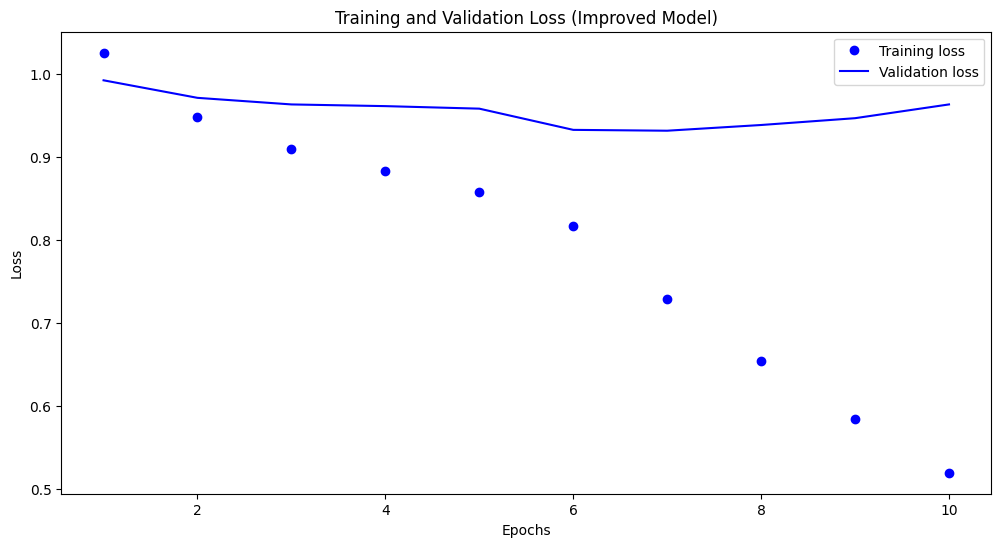

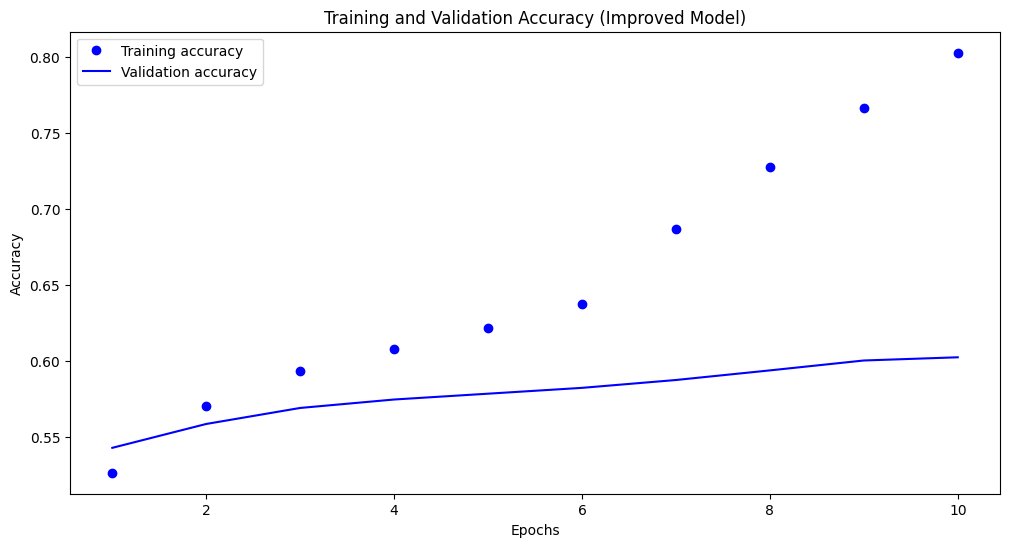

In [40]:
# Combine history from initial training and fine-tuning
total_epochs = len(history_improved.history['loss']) + len(history_fine_tune_improved.history['loss'])
epochs = range(1, total_epochs + 1)

train_loss = history_improved.history['loss'] + history_fine_tune_improved.history['loss']
val_loss = history_improved.history['val_loss'] + history_fine_tune_improved.history['val_loss']
train_accuracy = history_improved.history['accuracy'] + history_fine_tune_improved.history['accuracy']
val_accuracy = history_improved.history['val_accuracy'] + history_fine_tune_improved.history['val_accuracy']

# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(epochs, train_loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss (Improved Model)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Plot training and validation accuracy
plt.figure(figsize=(12, 6))
plt.plot(epochs, train_accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy (Improved Model)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Make Predictions

### Subtask:
Use the trained model to predict the damage type for new images.

**Reasoning**:
Load a sample image, preprocess it, use the trained model to predict the class probabilities, and interpret the results to get the predicted damage type.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step


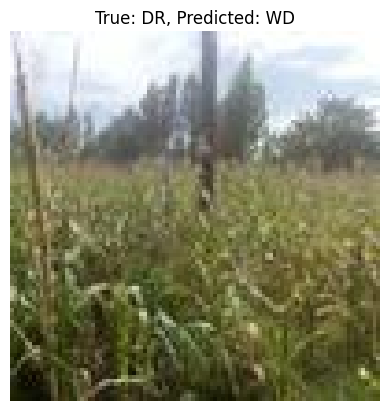

Sample Image: 389474b3bc621f3a80e0d737e7da7677f091ca25.jpg
True Label: DR
Predicted Label: WD
Prediction Probabilities: [0.68273044 0.2706713  0.04045488 0.00177414 0.00436924]


In [33]:
# Get a sample image path and true label from the test set
sample_filepath = X_test['filepath'].iloc[0]
sample_true_label_encoded = X_test['damage_encoded'].iloc[0]
sample_true_label = X_test['damage'].iloc[0]

# Preprocess the image for prediction
img_for_prediction = tf.io.read_file(sample_filepath)
img_for_prediction = tf.image.decode_jpeg(img_for_prediction, channels=3)
img_for_prediction = tf.image.convert_image_dtype(img_for_prediction, tf.float32)
img_for_prediction = tf.image.resize(img_for_prediction, size)  # Resize to the target size

# Add a batch dimension (models expect input in batches)
img_for_prediction = tf.expand_dims(img_for_prediction, axis=0)

# Make a prediction using the improved model
predictions = model_improved.predict(img_for_prediction)

# Get the predicted class index
predicted_class_index = tf.argmax(predictions, axis=1).numpy()[0]

# Map the predicted class index back to the damage label
reverse_label_map = {i: label for label, i in label_map.items()}
predicted_label = reverse_label_map[predicted_class_index]

# Load and display the image for visualization
img_display = mpimg.imread(sample_filepath)
plt.imshow(img_display)
plt.title(f"True: {sample_true_label}, Predicted: {predicted_label}")
plt.axis('off')
plt.show()

print(f"Sample Image: {os.path.basename(sample_filepath)}")
print(f"True Label: {sample_true_label}")
print(f"Predicted Label: {predicted_label}")
print(f"Prediction Probabilities: {predictions[0]}")

## Save the Model

In [37]:
# Save the improved model in the native Keras format
model_improved.save('crop_damage_model.keras')
print("Improved model saved successfully.")

Improved model saved successfully.


## Visualize Predictions for a Batch of Images

### Subtask:
Display a batch of sample images from the test set along with their true and predicted damage types.

**Reasoning**:
Get a batch of images and labels from the test dataset, make predictions for the batch, and then iterate through the batch to display each image with its true and predicted label.

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


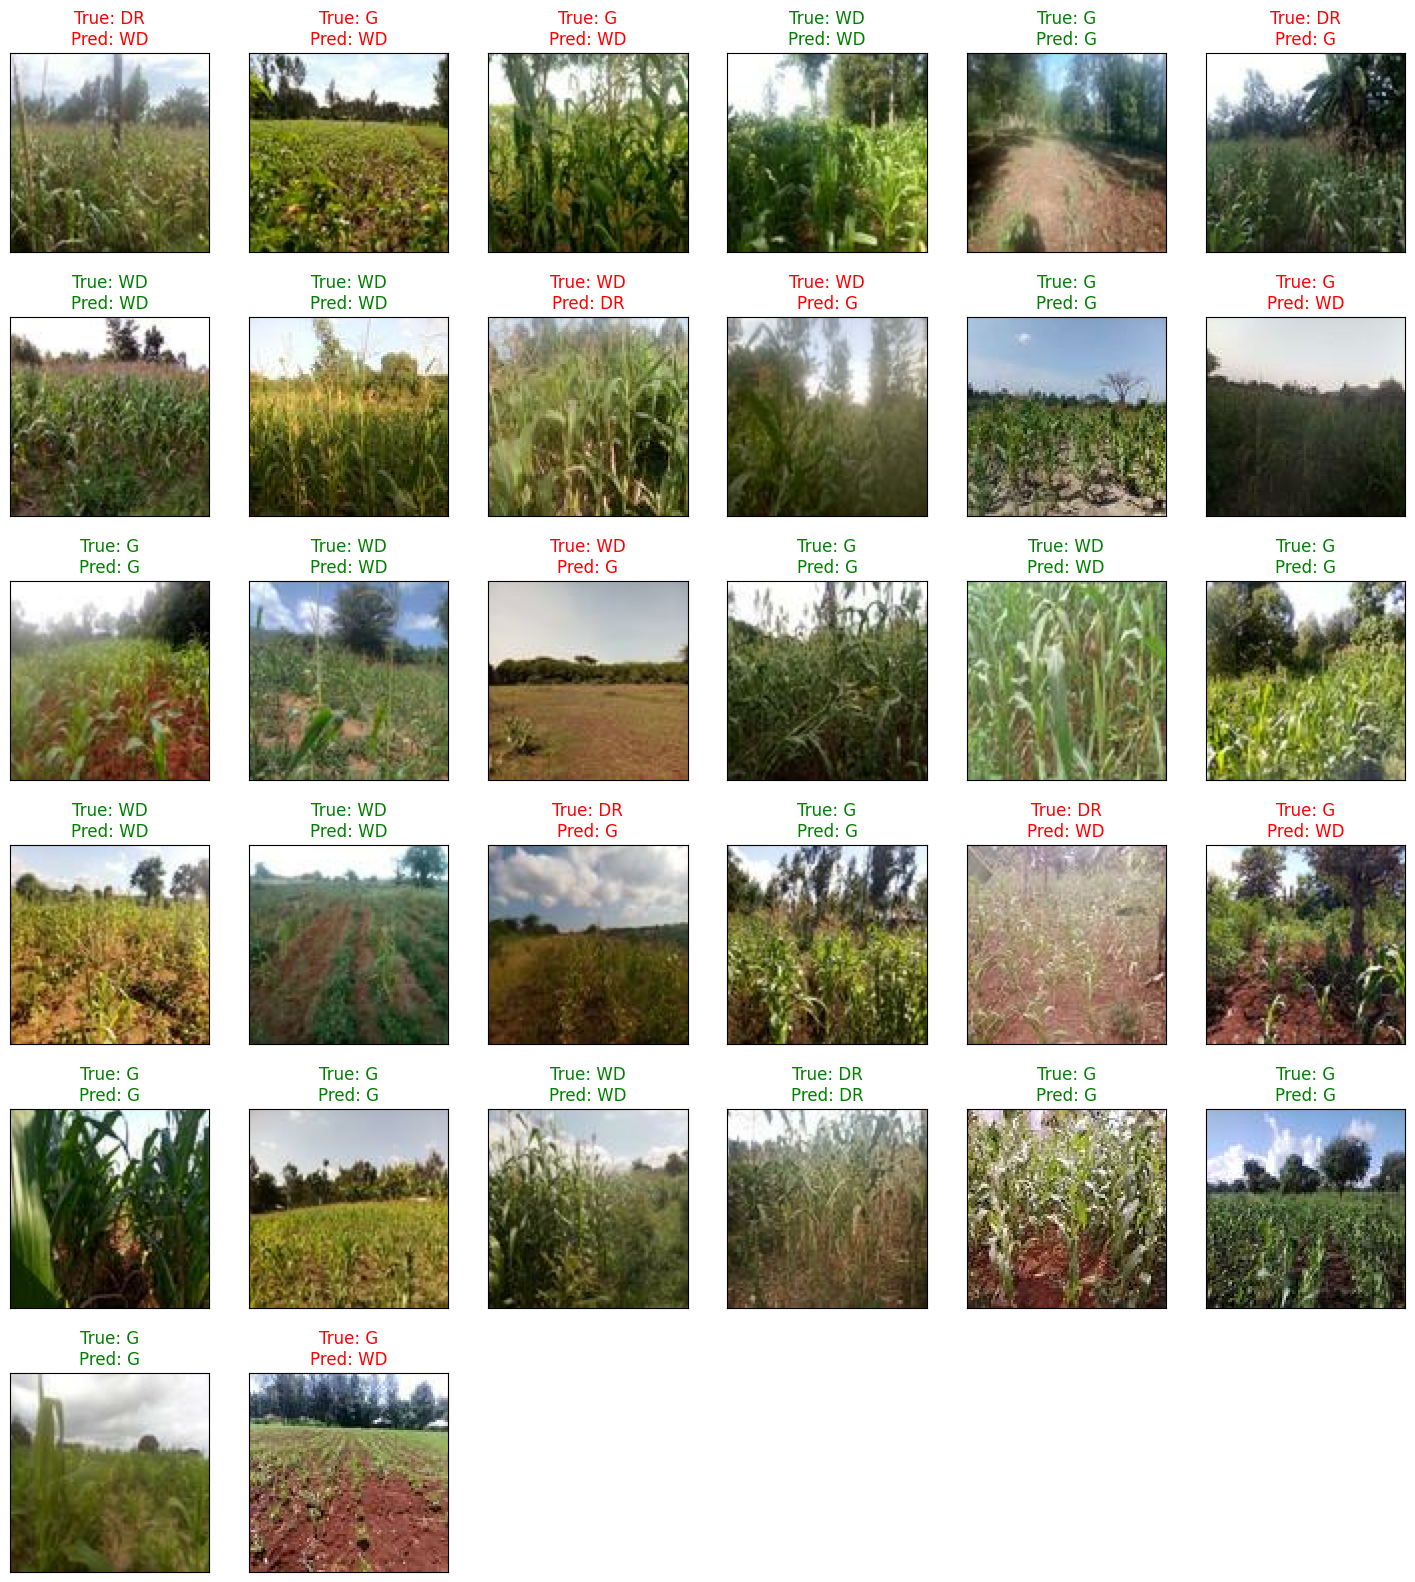

In [36]:
# Get a batch of images and labels from the test dataset
# We will take the first batch for demonstration
for images_batch, labels_batch in test_ds_improved.take(1):
    # Make predictions for the batch
    predictions_batch = model_improved.predict(images_batch)

    # Display each image in the batch with true and predicted labels
    plt.figure(figsize=(18, 20))
    for i in range(images_batch.shape[0]):
        plt.subplot(6, 6, i + 1) # Adjust subplot grid size as needed
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)

        # Display the image
        plt.imshow(images_batch[i].numpy())

        # Get true and predicted labels
        true_label_encoded = tf.argmax(labels_batch[i]).numpy() # Get index from one-hot
        true_label = reverse_label_map[true_label_encoded]

        predicted_class_index = tf.argmax(predictions_batch[i]).numpy()
        predicted_label = reverse_label_map[predicted_class_index]

        # Set title with true and predicted labels
        color = 'green' if predicted_label == true_label else 'red'
        plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)

    plt.show()

Loading the model

In [8]:
!ls -lh crop_damage_model.keras

ls: cannot access 'crop_damage_model.keras': No such file or directory


In [38]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model('crop_damage_model.keras')

print("Model loaded successfully.")

Model loaded successfully.
